<a href="https://colab.research.google.com/github/RenatGreen-flag/Model-Liniar-Regression/blob/main/linearRegressionGoldnIDR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INFORMASI DATASET**

Dataset ini berisi data historis **Harga Emas Dunia dan Indeks USD/IDR** yang dikumpulkan oleh Yahoo Finance dalam rentang waktu **2023 hingga sekarang**.

**Sumber Data**: Yahoo Finance - Gold Price, Indeks USD/IDR (2023-Sekarang)

**Parameter (Fitur)**:

* usdidr_close: Indeks USD ke IDR Tutup

**Target**: gold_cLose (Harga Komoditas Emas Dunia Tutup)








In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ydata-profiling
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.9 MB/s eta 0:00:00


/tmp/ipykernel_1986/3012752857.py:12: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


**# Langkah 1 Mengambil Data Dari Library YFinance**



1.   Ambil data harga emas dan indeks nilsi tukar USD/IDR
2.   Gunakan ticker symbol yang tersedia di yfinance.
3. Gunakan dictionary untuk memudahkan pengambilan data.
4. Tentukan rentang pengambilan data, saya menggunakan data historis dari januari 2023 - sekarang.
5.




In [2]:
TROY_OUNCE_TO_GRAM = 31.1035   # 1 troy ounce = 31.1035 gram
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Ticker global untuk memperkuat sinyal prediksi emas lokal
ticker_map = {
    "GC=F"    : "gold",         # Emas Dunia
    "USDIDR=X": "usdidr",       # Kurs USD ke IDR
    "DX-Y.NYB": "dxy",          # Indeks Dolar AS
    "^TNX"    : "us_yield",     # Suku Bunga Obligasi AS 10-Tahun
    "SI=F"    : "silver",       # Harga Perak Dunia
    "^VIX"    : "vix",          # Indeks Kepanikan Pasar
}

In [3]:
# Konfigurasi LAGSTEP ROLLING DLL
START = "2023-01-01"
END   = datetime.today().strftime("%Y-%m-%d")

LAG_STEPS       = [1, 2, 3, 5, 7]
ROLLING_WINDOWS = [3, 5, 10]

raw = yf.download(
    tickers     = list(ticker_map.keys()),
    start       = START,
    end         = END,
    auto_adjust = True,
    progress    = True,
)
df = raw["Close"].rename(columns=ticker_map).add_suffix("_close")
print(f"\nShape setelah download: {df.shape}")
print(df.tail(3))
print(f"Rentang tanggal awal  : {df.index.min().date()} s.d. {df.index.max().date()}")


[*********************100%***********************]  6 of 6 completed


Shape setelah download: (906, 6)
Ticker      dxy_close  gold_close  silver_close  usdidr_close  us_yield_close  \
Date                                                                            
2026-06-24     101.61     3990.30         58.05      17916.00            4.40   
2026-06-25     101.43     4030.50         58.35      17990.00            4.39   
2026-06-26     101.36     4078.70         59.22      17995.00            4.37   

Ticker      vix_close  
Date                   
2026-06-24      18.63  
2026-06-25      18.89  
2026-06-26      18.41  
Rentang tanggal awal  : 2023-01-02 s.d. 2026-06-26


In [4]:
# TAHAP 2: PENYELARASAN TIMEZONE (SHIFT +1 HARI)
GLOBAL_TICKERS = list(ticker_map.keys())
for ticker_name in GLOBAL_TICKERS:
  col = f"{ticker_map[ticker_name]}_close"
  if col in df.columns:
    df[col] = df[col].shift(1)


In [5]:
# TAHAP 3: REINDEX KE KALENDER HARIAN PENUH
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
df = df.reindex(full_range)
df.index.name = "Date"
print(f"Shape telah reindex: {df.shape}")


Shape telah reindex: (1272, 6)


In [6]:
# TAHAP 4: FORWARD FILL (FFILL) -> HARGA CLOSE HARI TERAKHIR

price_cols = [c for c in df.columns if c.endswith("_close")]
df[price_cols] = df[price_cols].ffill().bfill()


missing_after = df[price_cols].isnull().sum()
print(f"\nJumlah missing value setelah forward fill:\n{missing_after}")
print()



Jumlah missing value setelah forward fill:
Ticker
dxy_close         0
gold_close        0
silver_close      0
usdidr_close      0
us_yield_close    0
vix_close         0
dtype: int64



In [7]:
# TAHAP 5: FEATURE ENGINEERING (HARGA & RETURN)
df["gold_close_idr_per_oz"] = df["gold_close"] * df['usdidr_close']
df["gold_close_idr_per_gram"] = df["gold_close_idr_per_oz"] / TROY_OUNCE_TO_GRAM

# Hitung return harian untuk semua aset global
return_cols = []
for ticker_name in ticker_map.keys():
    name = ticker_map[ticker_name]
    df[f'{name}_return'] = df[f'{name}_close'].pct_change()
    return_cols.append(f'{name}_return')

# Hitung return untuk harga emas rupiah lokal
df['gold_idr_return'] = df['gold_close_idr_per_gram'].pct_change()
return_cols.append('gold_idr_return')


# Buat fitur lag dan rolling mean
features = []
for lag in LAG_STEPS:
    for col in return_cols:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag) #Fitur Lag disini berfungsi sebagai Memori pada model yang menyimmpan data deret waktu selama 7 hari yg lalu
        features.append(f'{col}_lag_{lag}') #Memasukan Lag pada colong _lag

for window in ROLLING_WINDOWS:
    for col in return_cols:
        df[f'{col}_roll_mean_{window}'] = df[col].rolling(window=window).mean() #Fitur Rolling windows disini berfungsi sebagai rearata atau tren melihat. apakah harga emas 7 hari yg lalu itu naik atau turun
        features.append(f'{col}_roll_mean_{window}')



In [8]:

# Lalu setelah itu buat target Multioutput dari data lag dan juga rollingnya untuk memprediksi 7 hari kedepan
targets = []
for h in range(1, 8):
    df[f'target_return_h{h}'] = df['gold_idr_return'].shift(-h)
    targets.append(f'target_return_h{h}')

# Simpan baris terakhir data riil untuk memprediksi masa depan aktual
df_future = df.iloc[-1:]

# Hapus missing values pada data training (akan menghapus 7 baris terakhir karena shift(-h))
df_clean = df.dropna(subset=features + targets)

X = df_clean[features]
y = df_clean[targets]

In [9]:
# Pecah data dan masukan pada model yang sesuai yaini ridge regresion

# TAHAP 6: MODELLING & HYPERPARAMETER TUNING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# GridSearch Ridge Regression
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train) #Memasukan data yang sudah dipisah kedalam Model Rigde Regresion

best_model = grid_search.best_estimator_
print(f"\nParameter Terbaik Ditemukan (Ridge Alpha): {grid_search.best_params_['alpha']}")


Parameter Terbaik Ditemukan (Ridge Alpha): 1000.0


In [10]:

# Prediksi return data uji
y_pred_returns = best_model.predict(X_test)

# Evaluasi R2 Score untuk harga rekonstruksi dari H+1 s.d. H+7
print("\n=== Evaluasi R2 Score & Standard Deviasi Error (Data Uji) ===")
price_today_test = df.loc[X_test.index, 'gold_close_idr_per_gram']
pred_tomorrow_h1 = None # Untuk diplot nanti
price_stds = [] # Standar deviasi error untuk rentang ketidakpastian harga

for h in range(1, 8):
    actual_h = df.loc[X_test.index].shift(-h)['gold_close_idr_per_gram']
    pred_h = price_today_test.copy()
    for j in range(1, h + 1):
        pred_h *= (1 + y_pred_returns[:, j-1])

    if h == 1:
        pred_tomorrow_h1 = pred_h

    valid_idx = actual_h.dropna().index
    r2_h = r2_score(actual_h.loc[valid_idx], pred_h.loc[valid_idx])

    # Hitung standar deviasi error absolut harga
    error_h = actual_h.loc[valid_idx] - pred_h.loc[valid_idx]
    std_h = np.std(error_h)
    price_stds.append(std_h)

    print(f"Prediksi H+{h}: R2 Score = {r2_h:.5f} | Standard Error = Rp {std_h:,.2f}")



=== Evaluasi R2 Score & Standard Deviasi Error (Data Uji) ===
Prediksi H+1: R2 Score = 0.95428 | Standard Error = Rp 43,663.19
Prediksi H+2: R2 Score = 0.90959 | Standard Error = Rp 61,127.70
Prediksi H+3: R2 Score = 0.87321 | Standard Error = Rp 72,212.15
Prediksi H+4: R2 Score = 0.83526 | Standard Error = Rp 82,128.50
Prediksi H+5: R2 Score = 0.80252 | Standard Error = Rp 89,750.34
Prediksi H+6: R2 Score = 0.76874 | Standard Error = Rp 97,013.22
Prediksi H+7: R2 Score = 0.73552 | Standard Error = Rp 103,614.98


In [11]:

# Hitung Akurasi Arah Harga H+1 pada hari aktif trading
actual_direction_h1 = np.sign(y_test['target_return_h1'])
pred_direction_h1 = np.sign(y_pred_returns[:, 0])
trading_days_mask = actual_direction_h1 != 0
direction_accuracy = np.mean(actual_direction_h1[trading_days_mask] == pred_direction_h1[trading_days_mask]) * 100
print(f"\nAkurasi Arah Naik/Turun H+1 (Trading Days): {direction_accuracy:.2f}%")

# PREDIKSI MASA DEPAN (7 Hari ke Depan dari hari ini)
last_features = df_future[features]
last_date = df_future.index[0]
last_price = df_future['gold_close_idr_per_gram'].values[0]

future_returns = best_model.predict(last_features)[0]

print(f"\n=== FORECAST HARGA EMAS & PREDICTION INTERVAL 95% (Mulai {last_date.date()}) ===")
current_price = last_price
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')
forecast_prices = []
lower_bounds = []
upper_bounds = []

for i, date in enumerate(forecast_dates):
    current_price *= (1 + future_returns[i])
    forecast_prices.append(current_price)

    # 95% Confidence/Prediction Interval = Prediksi +/- 1.96 * Standard Error
    margin_of_error = 1.96 * price_stds[i]
    lower_bound = max(0.0, current_price - margin_of_error)
    upper_bound = current_price + margin_of_error
    lower_bounds.append(lower_bound)
    upper_bounds.append(upper_bound)

    print(f"{date.date()} (H+{i+1}): Rp {current_price:,.2f} [Rentang: Rp {lower_bound:,.2f} - Rp {upper_bound:,.2f}]")


Akurasi Arah Naik/Turun H+1 (Trading Days): 54.80%

=== FORECAST HARGA EMAS & PREDICTION INTERVAL 95% (Mulai 2026-06-26) ===
2026-06-27 (H+1): Rp 2,333,227.66 [Rentang: Rp 2,247,647.81 - Rp 2,418,807.52]
2026-06-28 (H+2): Rp 2,335,240.12 [Rentang: Rp 2,215,429.84 - Rp 2,455,050.41]
2026-06-29 (H+3): Rp 2,337,339.00 [Rentang: Rp 2,195,803.20 - Rp 2,478,874.81]
2026-06-30 (H+4): Rp 2,339,432.78 [Rentang: Rp 2,178,460.93 - Rp 2,500,404.64]
2026-07-01 (H+5): Rp 2,341,568.05 [Rentang: Rp 2,165,657.39 - Rp 2,517,478.71]
2026-07-02 (H+6): Rp 2,343,750.36 [Rentang: Rp 2,153,604.44 - Rp 2,533,896.28]
2026-07-03 (H+7): Rp 2,345,965.06 [Rentang: Rp 2,142,879.69 - Rp 2,549,050.43]


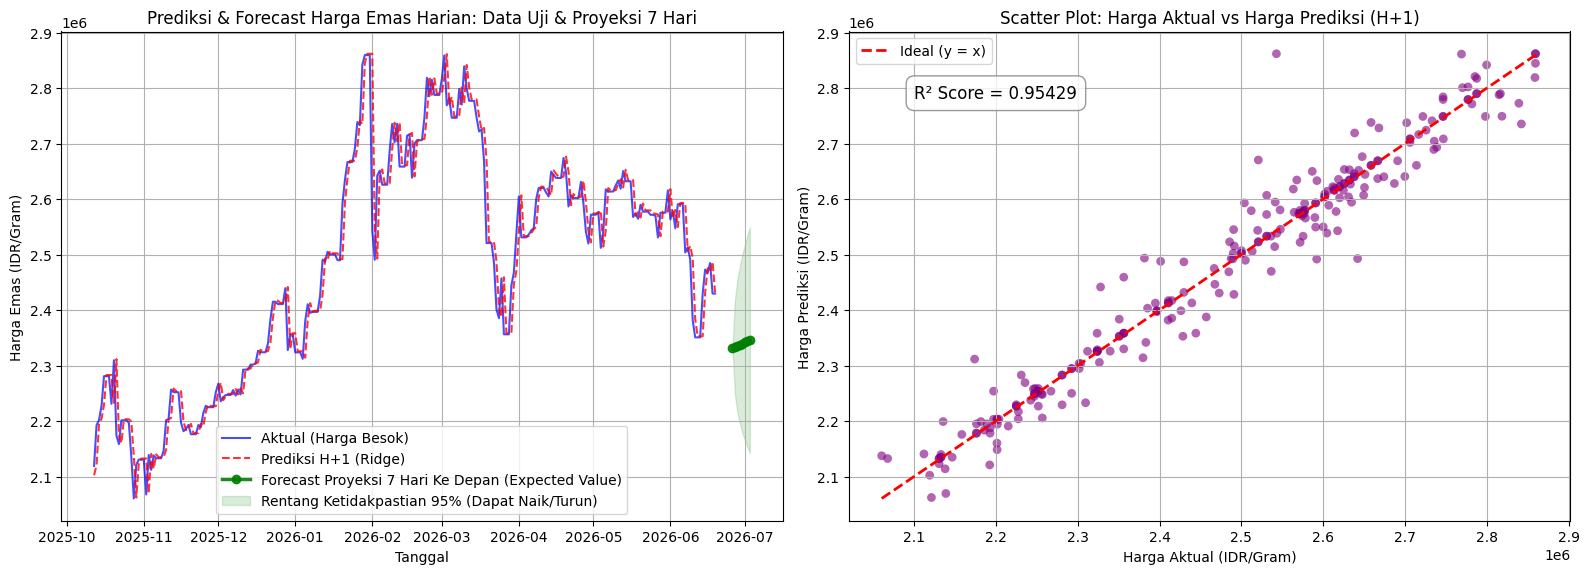

In [12]:

# --- TAHAP 7: VISUALISASI HASIL PREDIKSI & FORECAST ---
plt.figure(figsize=(16, 6))

# Subplot 1: Time Series Plot
plt.subplot(1, 2, 1)
test_dates = X_test.index
actual_tomorrow = price_today_test * (1 + y_test['target_return_h1'])
plt.plot(test_dates, actual_tomorrow, label='Aktual (Harga Besok)', color='blue', alpha=0.7)
plt.plot(test_dates, pred_tomorrow_h1, label='Prediksi H+1 (Ridge)', color='red', linestyle='--', alpha=0.8)

# Hubungkan hari terakhir data uji dengan forecast pertama untuk kesinambungan garis
plt.plot(
    [last_date] + list(forecast_dates),
    [last_price] + forecast_prices,
    label='Forecast Proyeksi 7 Hari Ke Depan (Expected Value)',
    color='green',
    linewidth=2.5,
    marker='o',
    alpha=0.9
)

# Plot Shaded Area untuk Prediction Interval 95% (Menunjukkan Ketidakpastian/Dinamika Pasar)
plt.fill_between(
    [last_date] + list(forecast_dates),
    [last_price] + lower_bounds,
    [last_price] + upper_bounds,
    color='green',
    alpha=0.15,
    label='Rentang Ketidakpastian 95% (Dapat Naik/Turun)'
)

plt.title('Prediksi & Forecast Harga Emas Harian: Data Uji & Proyeksi 7 Hari')
plt.xlabel('Tanggal')
plt.ylabel('Harga Emas (IDR/Gram)')
plt.legend()
plt.grid(True)

# Subplot 2: Scatter Plot (Uji Prediksi vs Aktual)
plt.subplot(1, 2, 2)
plt.scatter(actual_tomorrow, pred_tomorrow_h1, alpha=0.6, color='purple', edgecolors='none', s=40)
# Garis diagonal 45 derajat (y=x)
min_val = min(actual_tomorrow.min(), pred_tomorrow_h1.min())
max_val = max(actual_tomorrow.max(), pred_tomorrow_h1.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal (y = x)')

plt.title('Scatter Plot: Harga Aktual vs Harga Prediksi (H+1)')
plt.xlabel('Harga Aktual (IDR/Gram)')
plt.ylabel('Harga Prediksi (IDR/Gram)')
# Tampilkan teks R2 di dalam plot
r2_price_h1 = r2_score(actual_tomorrow, pred_tomorrow_h1)
plt.text(
    min_val + (max_val - min_val)*0.05,
    max_val - (max_val - min_val)*0.1,
    f'R² Score = {r2_price_h1:.5f}',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5')
)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('emas_actual_vs_predicted.png', dpi=300)